# 🛒 SmartCart — Customer Segmentation

In [223]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from kneed import KneeLocator
import numpy as np
import pickle

## 1. Load Data

In [224]:
df = pd.read_csv("smartcart_customers.csv")
print('Shape:', df.shape)
df.head()

Shape: (2240, 22)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [225]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

## 2. Handle Missing Values

In [226]:
df['Income'] = df['Income'].fillna(df['Income'].median())

## 3. Feature Engineering

In [227]:
# Age
df['Age'] = 2026 - df['Year_Birth']

# Customer Tenure
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)
reference_date = df['Dt_Customer'].max()
df['Customer_Tenure_Days'] = (reference_date - df['Dt_Customer']).dt.days

# Total Spending
df['Total_Spending'] = (
    df['MntWines'] + df['MntFruits'] + df['MntMeatProducts']
    + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']
)

# Total Children
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

# Education
df['Education'] = df['Education'].replace({
    'Basic': 'Undergraduate', '2n Cycle': 'Undergraduate',
    'Graduation': 'Graduate',
    'Master': 'Postgraduate', 'PhD': 'Postgraduate'
})

# Living With
df['Living_With'] = df['Marital_Status'].replace({
    'Married': 'Partner', 'Together': 'Partner',
    'Single': 'Alone', 'Divorced': 'Alone',
    'Widow': 'Alone', 'Absurd': 'Alone', 'YOLO': 'Alone'
})

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


## 4. Drop Columns

In [228]:
cols_to_drop = (
    ['ID', 'Year_Birth', 'Marital_Status', 'Kidhome', 'Teenhome', 'Dt_Customer']
    + ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
)
df_cleaned = df.drop(columns=cols_to_drop)
df_cleaned.shape

(2240, 15)

## 5. Remove Outliers

In [229]:
print('Before:', len(df_cleaned))
df_cleaned = df_cleaned[df_cleaned['Age'] < 90]
df_cleaned = df_cleaned[df_cleaned['Income'] < 600_000]
print('After:', len(df_cleaned))

Before: 2240
After: 2236


## 6. Pairplot

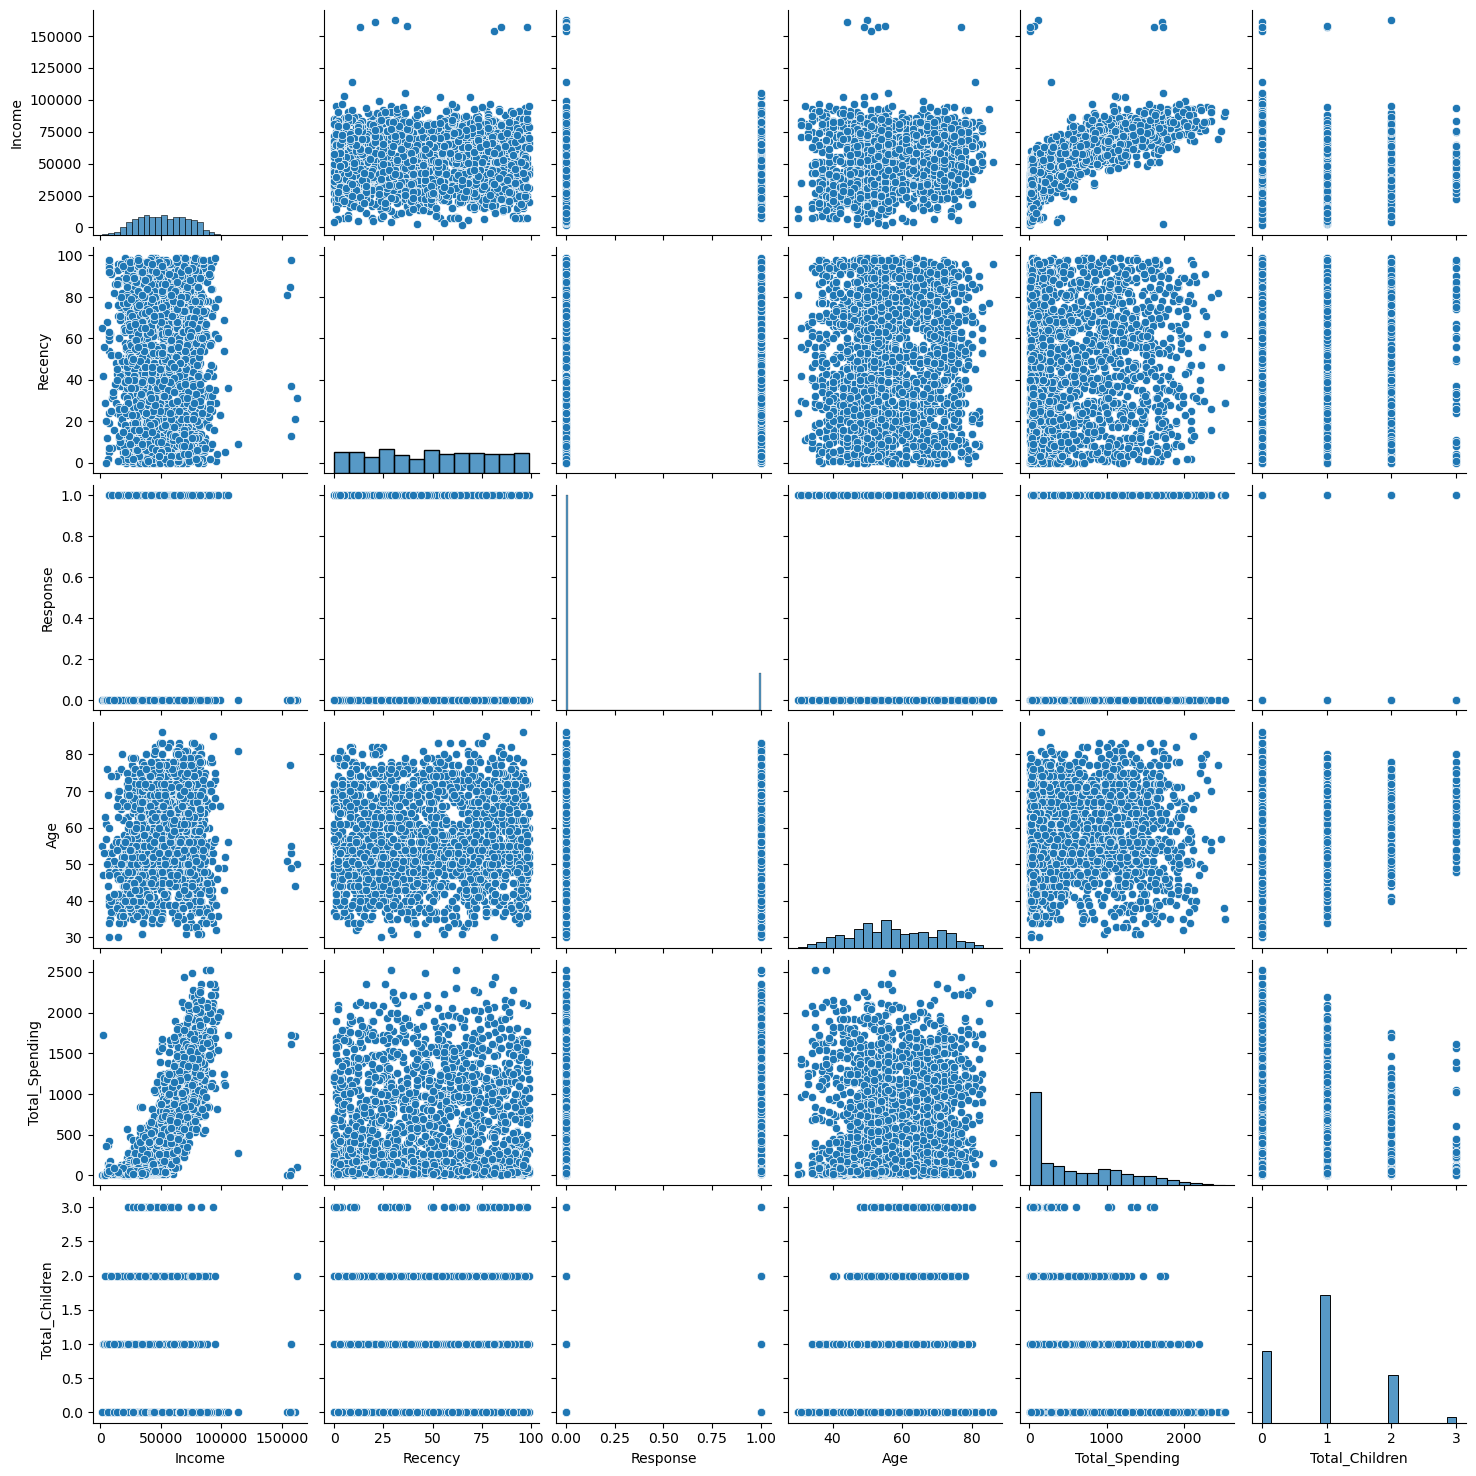

In [230]:
pair_cols = ['Income', 'Recency', 'Response', 'Age', 'Total_Spending', 'Total_Children']
sns.pairplot(df_cleaned[pair_cols])
plt.show()

## 7. Correlation Heatmap

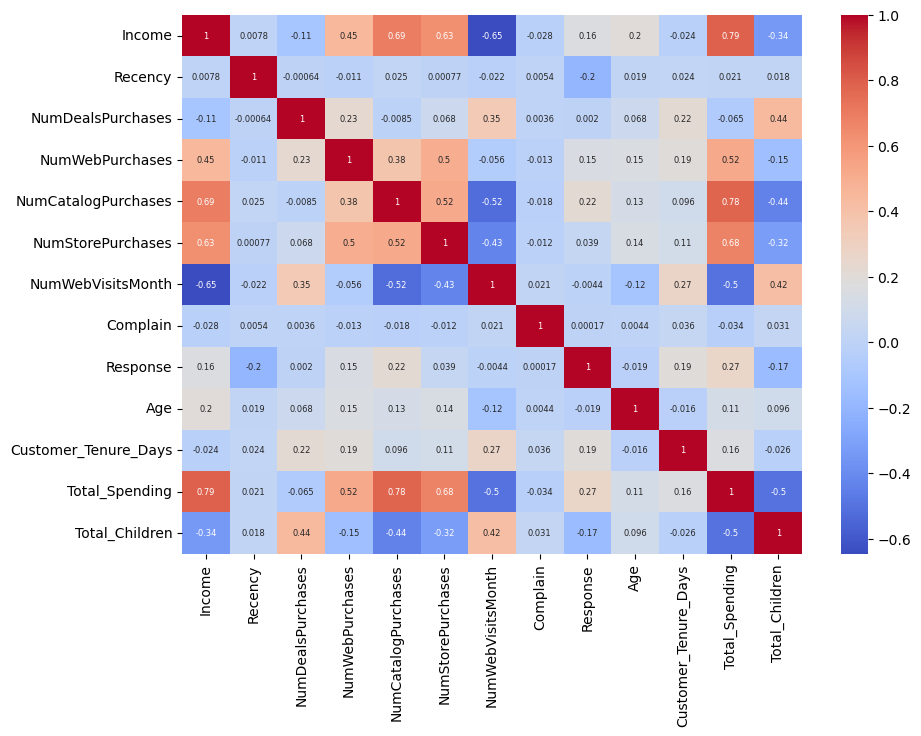

In [231]:
corr = df_cleaned.corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, annot_kws={'size': 6}, cmap='coolwarm')
plt.show()

## 8. Encoding

In [232]:
ohe = OneHotEncoder()
cat_cols = ['Education', 'Living_With']
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])
enc_df = pd.DataFrame(
    enc_cols.toarray(),
    columns=ohe.get_feature_names_out(cat_cols),
    index=df_cleaned.index
)
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols), enc_df], axis=1)
df_encoded.shape

(2236, 18)

## 9. Scaling

In [233]:
scaler = StandardScaler()
X = df_encoded.copy()
feature_cols = X.columns.tolist()
X_scaled = scaler.fit_transform(X)
print('Feature columns:', feature_cols)

Feature columns: ['Income', 'Recency', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spending', 'Total_Children', 'Education_Graduate', 'Education_Postgraduate', 'Education_Undergraduate', 'Living_With_Alone', 'Living_With_Partner']


## 10. PCA

Explained variance: [0.23163158 0.11385454 0.10405815]


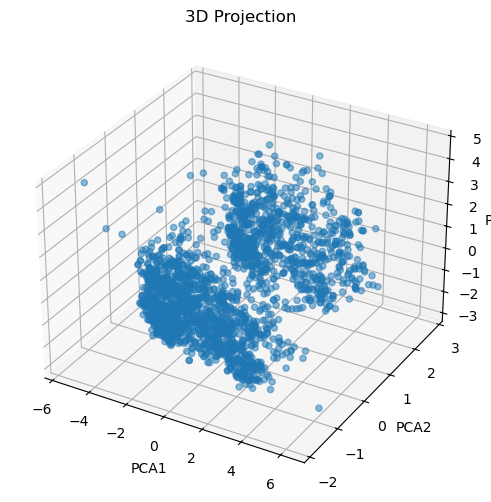

In [234]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)
print('Explained variance:', pca.explained_variance_ratio_)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], alpha=0.5)
ax.set_xlabel('PCA1')
ax.set_ylabel('PCA2')
ax.set_zlabel('PCA3')
ax.set_title('3D Projection')
plt.show()

## 11. Elbow Method

Optimal K: 4


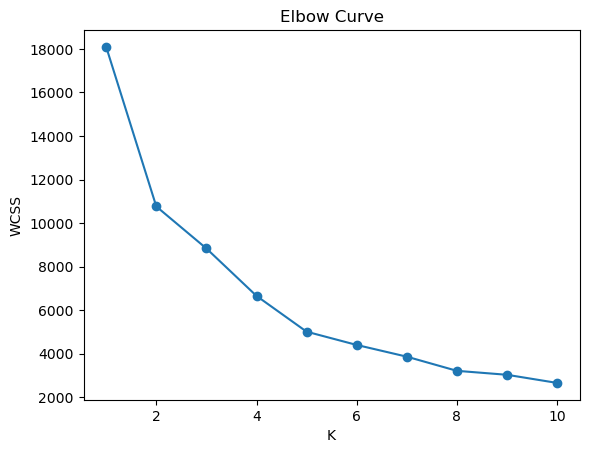

In [235]:
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit_predict(X_pca)
    wcss.append(km.inertia_)

knee = KneeLocator(range(1, 11), wcss, curve='convex', direction='decreasing')
print('Optimal K:', knee.elbow)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('K')
plt.ylabel('WCSS')
plt.title('Elbow Curve')
plt.show()

## 12. Silhouette Score

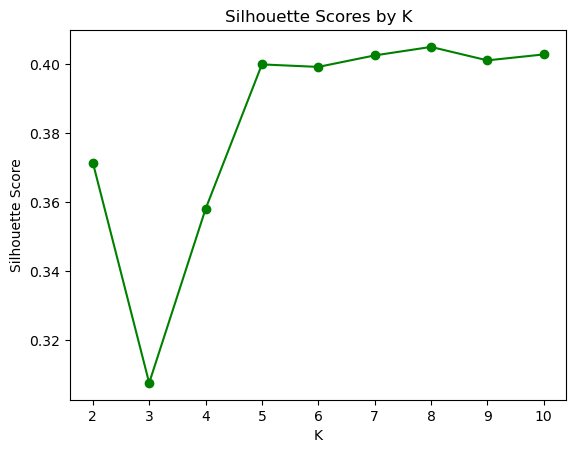

In [236]:
scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_pca)
    scores.append(silhouette_score(X_pca, labels))

plt.plot(range(2, 11), scores, marker='o', color='green')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores by K')
plt.show()

## 13. KMeans Clustering

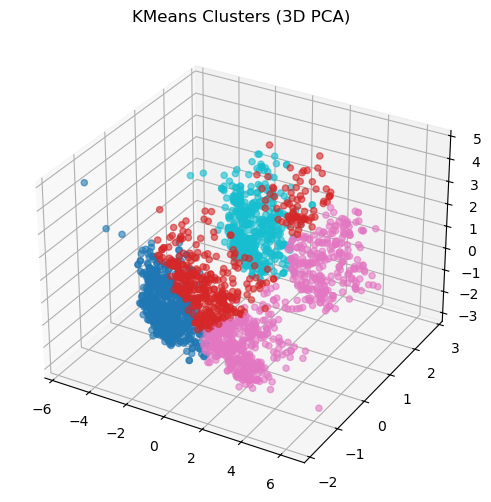

In [237]:
kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_kmeans, cmap='tab10', alpha=0.6)
ax.set_title('KMeans Clusters (3D PCA)')
plt.show()

## 14. Agglomerative Clustering

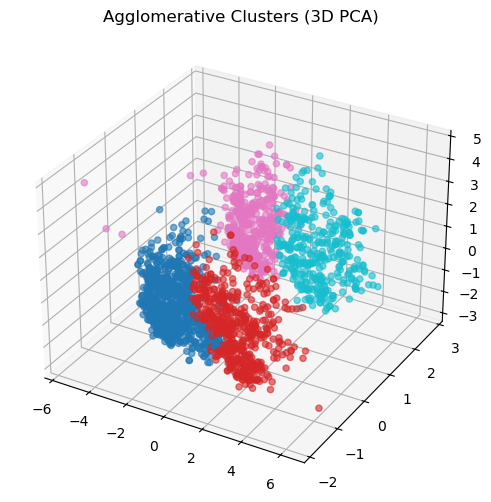

In [238]:
agg_clf = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_agg = agg_clf.fit_predict(X_pca)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_agg, cmap='tab10', alpha=0.6)
ax.set_title('Agglomerative Clusters (3D PCA)')
plt.show()

## 15. Cluster Characterization

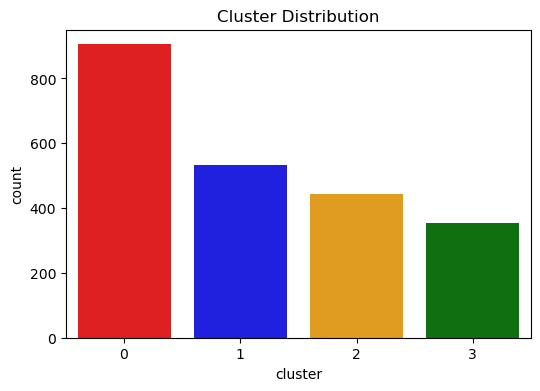

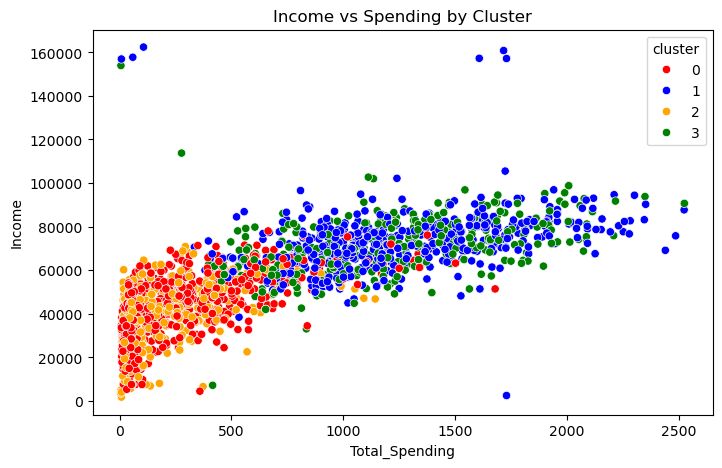

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
cluster,,,,,,,,,,,,,,,,,,
0,39680.580110,48.914917,2.594475,3.153591,0.969061,4.143646,6.307182,0.011050,0.076243,55.669613,342.939227,221.955801,1.243094,0.514917,0.338122,0.146961,0.000000,1.000000
1,72808.445693,49.202247,1.958801,5.687266,5.498127,8.659176,3.580524,0.005618,0.166667,59.492509,369.720974,1236.588015,0.511236,0.471910,0.455056,0.073034,0.000000,1.000000
2,36960.143018,48.319820,2.594595,2.713964,0.837838,3.623874,6.659910,0.011261,0.141892,55.691441,338.781532,165.702703,1.272523,0.488739,0.378378,0.132883,0.993243,0.006757
3,70722.681303,50.504249,1.855524,5.790368,5.014164,8.430595,3.728045,0.005666,0.320113,58.932011,376.280453,1190.385269,0.461756,0.541076,0.390935,0.067989,1.000000,0.000000


In [239]:
X['cluster'] = labels_agg
pal = ['red', 'blue', 'orange', 'green']

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='cluster', data=X, hue='cluster', palette=pal, ax=ax, legend=False)
ax.set_title('Cluster Distribution')
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(x=X['Total_Spending'], y=X['Income'], hue=X['cluster'], palette=pal, ax=ax)
ax.set_title('Income vs Spending by Cluster')
plt.show()

cluster_summary = X.groupby('cluster').mean()
cluster_summary

## 16. Save Model to model.pkl

In [240]:
with open('model.pkl', 'wb') as f:
    pickle.dump({
        'kmeans': kmeans,
        'scaler': scaler,
        'pca': pca,
        'ohe': ohe,
        'feature_cols': feature_cols,
        'labels_kmeans': labels_kmeans,
        'labels_agg': labels_agg,
        'X_pca': X_pca,
        'X': X,
        'df_cleaned': df_cleaned,
        'cluster_summary': cluster_summary,
    }, f)

print('✅ model.pkl saved successfully!')

✅ model.pkl saved successfully!
